In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
import sys

WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))

from wave_tools.utils import create_colormap


In [2]:

def load_composite_data(var_name='wa', composite_dir='../composite_data/'):
    """
    加载已保存的合成数据
    
    Parameters:
    -----------
    var_name : str
        变量名 ('wa', 'ua', 'va', 'pr', 'hus')
    composite_dir : str
        数据目录
    
    Returns:
    --------
    data_dict : dict
        {exp: xr.DataArray} 合成数据
    """
    exp_list = ['CNTL', 'P4K', '4CO2']
    
    print(f"\n📂 Loading {var_name} composite data...")
    data_dict = {}
    
    for exp in exp_list:
        # 尝试不同的文件名格式
        possible_files = [
            f'{var_name}_composite_{exp.lower()}_with_height.nc',
            f'{var_name}_composite_{exp.lower()}.nc',
            f'kelvin_{var_name}_{exp.lower()}_composite.nc'
        ]
        
        loaded = False
        for filename in possible_files:
            filepath = os.path.join(composite_dir, filename)
            if os.path.exists(filepath):
                try:
                    ds = xr.open_dataset(filepath, decode_timedelta=False)
                    # 尝试提取变量
                    if var_name in ds:
                        data = ds[var_name]
                    elif 'wa' in ds and var_name == 'omega':
                        data = ds['wa']
                    else:
                        data = ds[list(ds.data_vars)[0]]
                    
                    data_dict[exp] = data
                    print(f"  ✅ {exp}: {filename}, Shape: {data.shape}")
                    loaded = True
                    break
                except Exception as e:
                    continue
        
        if not loaded:
            print(f"  ⚠️  {exp}: File not found")
    
    return data_dict

# 加载wa数据
wa_composite_data = load_composite_data('wa')

hus_composite_data = load_composite_data('hus')



📂 Loading wa composite data...


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


  ✅ CNTL: wa_composite_cntl_with_height.nc, Shape: (9, 22, 15, 180)
  ✅ P4K: wa_composite_p4k_with_height.nc, Shape: (9, 22, 15, 180)
  ✅ 4CO2: wa_composite_4co2_with_height.nc, Shape: (9, 22, 15, 180)

📂 Loading hus composite data...
  ✅ CNTL: hus_composite_cntl_with_height.nc, Shape: (9, 22, 15, 180)
  ✅ P4K: hus_composite_p4k_with_height.nc, Shape: (9, 22, 15, 180)
  ✅ 4CO2: hus_composite_4co2_with_height.nc, Shape: (9, 22, 15, 180)


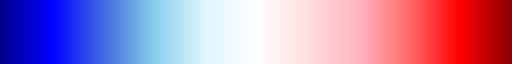

In [3]:
mycmap = create_colormap()
mycmap

In [1]:


def plot_hus_lon_height_composite(
        hus_composites,
        experiments=['CNTL', 'P4K', '4CO2'],
        lags=[-4, -2, 0, 2, 4],
        lat_range=(5, 15),
        lon_range=(200, 300),
        figsize=(20, 12),
        height_range=None):
    """
    绘制hus的经度-高度剖面组合图
    
    每行：3个实验 (CNTL, P4K, 4CO2)
    每列：不同的lag天数
    
    Parameters:
    -----------
    hus_composites : dict
        {exp: xr.DataArray} hus合成数据，维度应为 (lag, height, lat, lon)
    experiments : list
        实验列表
    lags : list
        要绘制的lag天数列表
    lat_range : tuple
        纬度范围
    lon_range : tuple
        经度范围
    figsize : tuple
        图形大小
    height_range : tuple or None
        高度范围（km），None表示使用全部
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
    """
    
    n_lags = len(lags)
    n_exps = len(experiments)
    
    # 创建子图：n_lags行 × n_exps列
    fig, axes = plt.subplots(n_lags, n_exps, figsize=figsize, dpi=150)
    
    # 如果只有一行或一列，确保axes是2D数组
    if n_lags == 1 and n_exps == 1:
        axes = np.array([[axes]])
    elif n_lags == 1:
        axes = axes.reshape(1, -1)
    elif n_exps == 1:
        axes = axes.reshape(-1, 1)
    
    # 实验标题
    exp_titles = {
        'CNTL': 'CNTL',
        'P4K': 'P4K',
        '4CO2': '4×CO₂'
    }
    titles_sub = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)']
    # 创建colormap
    colors_list = [
        '#313695', '#4575b4', '#74add1', '#abd9e9', '#e0f3f8',
        'white',
        '#fee090', '#fdae61', '#f46d43', '#d73027', '#a50026'
    ]
    cmap = LinearSegmentedColormap.from_list('hus_cmap', colors_list)
    
    
    # 设置colorbar范围（需要根据实际数据调整）
    vmin, vmax = -10e-5, 10e-5  # 单位：kg/kg
    levels = np.linspace(vmin, vmax, 21)
    
    print("\n" + "="*70)
    print("🎨 Plotting hus longitude-height composite")
    print("="*70)
    
    # 遍历每个lag和实验
    for row_idx, lag in enumerate(lags):
        for col_idx, exp in enumerate(experiments):
            ax = axes[row_idx, col_idx]
            ax.set_title(f"({chr(97 + row_idx * len(experiments) + col_idx)})", fontsize=14, loc='left')
            
            if exp not in hus_composites:
                print(f"  ⚠️  {exp} lag={lag}: Data not found")
                ax.text(0.5, 0.5, 'Data not available', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            
            hus_da = hus_composites[exp]
            
            # 识别高度维度名称
            if 'height' in hus_da.dims:
                height_dim = 'height'
            elif 'lev' in hus_da.dims:
                height_dim = 'lev'
            elif 'level' in hus_da.dims:
                height_dim = 'level'
            else:
                print(f"  ⚠️  {exp}: No height dimension found")
                continue
            
            # 数据选择：lag, lat平均, lon
            try:
                hus_data = (
                    hus_da
                    .sel(lag=lag, lat=slice(*lat_range), lon=slice(*lon_range))
                    .mean(dim='lat')
                )
            except Exception as e:
                print(f"  ⚠️  {exp} lag={lag}: Error selecting data - {str(e)}")
                continue
            
            # 获取坐标
            lon_vals = hus_data.lon.values
            height_vals = hus_data[height_dim].values  # 单位：km
            
            # 如果指定了高度范围，进行筛选
            if height_range is not None:
                mask = (height_vals >= height_range[0]) & (height_vals <= height_range[1])
                if mask.sum() == 0:
                    print(f"  ⚠️  {exp} lag={lag}: No data in specified height range")
                    continue
                hus_data = hus_data.isel({height_dim: mask})
                height_vals = height_vals[mask]
            
            # 创建网格
            LON, HEIGHT = np.meshgrid(lon_vals, height_vals)
            
            # 绘制填色图
            cf = ax.contourf(LON, HEIGHT, hus_data.values, 
                           levels=levels, cmap= mycmap, extend='neither')
            
            # 绘制等值线
            cs = ax.contour(LON, HEIGHT, hus_data.values, 
                          levels=levels[::2], colors='k', alpha=0.3, linewidths=0.5)
            
            # 设置y轴（高度）
            ax.set_ylim(height_vals.min(), 15)
            height_min = int(np.ceil(height_vals.min()))
            height_max = min(15, int(np.floor(height_vals.max())))
            yticks = np.arange(0, 15, 2)
            ax.set_yticks(yticks)
            ax.set_ylim(0,14)
            # 只在最左列显示y轴标签
            if col_idx == 0:
                ax.set_yticklabels([f"{int(h)}" for h in yticks], fontsize=12)
                ax.set_ylabel('Height (km)', fontsize=13)
            else:
                ax.set_yticklabels([])
            
            # 设置x轴（经度）
            def east_longitude_formatter(x, pos):
                val = x % 360
                return f"{int(val)}°E"
            from cartopy.mpl.ticker import LongitudeFormatter
            ax.xaxis.set_major_formatter(LongitudeFormatter())
            # ax.xaxis.set_major_formatter(plt.FuncFormatter(east_longitude_formatter))
            ax.set_xticks(np.arange(lon_range[0], lon_range[1]+1, 20))
            
            # 只在最下行显示x轴标签
            if row_idx == n_lags - 1:
                ax.tick_params(axis='x', labelsize=11)
                ax.set_xlabel('Longitude', fontsize=13)
            else:
                ax.set_xticklabels([])
                
                
           
            
            # 标题：最上行显示实验名，最左列显示lag
            if row_idx == 0:
                ax.set_title(f"{exp_titles.get(exp, exp)}", fontsize=14,y=1.05)
            
            if col_idx == 0:
                # 在图的左侧添加lag标签
                ax.text(-0.15, 0.5, f"Day {lag:+d}", 
                       transform=ax.transAxes, fontsize=13, 
                       rotation=90, va='center', ha='right')
            
            # 网格
            ax.grid(True, linestyle=':', alpha=0.3, linewidth=0.5)
            
            # 刻度参数
            ax.tick_params(which='both', direction='out', width=1.0,
                          labelsize=11, bottom=True, left=True, 
                          right=True, top=True)
            
            print(f"  ✅ {exp} lag={lag}: Plotted")
    
    # 调整子图间距
    plt.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                       hspace=0.15, wspace=0.1)
    
    # 添加全局colorbar
    cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.015])
    cbar = plt.colorbar(cf, cax=cbar_ax, orientation='horizontal', extend='both')
    cbar.set_label(r'Specific Humidity Anomaly (kg/kg)', fontsize=14, )
    cbar.ax.tick_params(labelsize=11)
    
    # 格式化colorbar刻度为科学计数法
    cbar.formatter.set_powerlimits((-2, 2))
    cbar.ax.xaxis.offsetText.set_fontsize(11)
    cbar.update_ticks()
    
    print("\n" + "="*70)
    print("✅ Plotting completed")
    print("="*70)
    
    return fig

# 使用示例
print("✅ Function defined: plot_hus_lon_height_composite")
print("\n💡 Usage:")
print("   fig = plot_hus_lon_height_composite(")
print("       hus_composite_data,")
print("       experiments=['CNTL', 'P4K', '4CO2'],")
print("       lags=[-4, -2, 0, 2, 4],")
print("       lat_range=(5, 15),")
print("       lon_range=(200, 300),")
print("       height_range=(0, 15)")
print("   )")
# 绘制hus经度-高度剖面组合图
print("\n🎨 Creating hus longitude-height composite figure...")

fig_hus = plot_hus_lon_height_composite(
    hus_composites=hus_composite_data,
    experiments=['CNTL', 'P4K', '4CO2'],
    lags=[-1, 0,],
    lat_range=(5, 15),
    lon_range=(200, 300),
    figsize=(18, 15),
    height_range=(0, 15)  # 0-15km高度范围
)


plt.show()

# 可选：保存图片
save_fig = True
if save_fig:
    save_dir = '../figures/vertical_profile_composite/'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, 'hus_lon_height_composite_all_lags.png')
    fig_hus.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n💾 Figure saved: {save_path}")
    

✅ Function defined: plot_hus_lon_height_composite

💡 Usage:
   fig = plot_hus_lon_height_composite(
       hus_composite_data,
       experiments=['CNTL', 'P4K', '4CO2'],
       lags=[-4, -2, 0, 2, 4],
       lat_range=(5, 15),
       lon_range=(200, 300),
       height_range=(0, 15)
   )

🎨 Creating hus longitude-height composite figure...


NameError: name 'hus_composite_data' is not defined

✅ Function defined: plot_wa_lon_height_composite

💡 Usage:
   fig = plot_wa_lon_height_composite(
       wa_composite_data,
       experiments=['CNTL', 'P4K', '4CO2'],
       lags=[-4, -2, 0, 2, 4],
       lat_range=(5, 15),
       lon_range=(200, 300),
       height_range=(0, 15)
   )

🎨 Creating wa longitude-height composite figure...

🎨 Plotting wa longitude-height composite
  ✅ CNTL lag=-4: Plotted
  ✅ P4K lag=-4: Plotted
  ✅ 4CO2 lag=-4: Plotted
  ✅ CNTL lag=-2: Plotted
  ✅ P4K lag=-2: Plotted
  ✅ 4CO2 lag=-2: Plotted
  ✅ CNTL lag=0: Plotted
  ✅ P4K lag=0: Plotted
  ✅ 4CO2 lag=0: Plotted
  ✅ CNTL lag=2: Plotted
  ✅ P4K lag=2: Plotted
  ✅ 4CO2 lag=2: Plotted
  ✅ CNTL lag=4: Plotted
  ✅ P4K lag=4: Plotted
  ✅ 4CO2 lag=4: Plotted

✅ Plotting completed


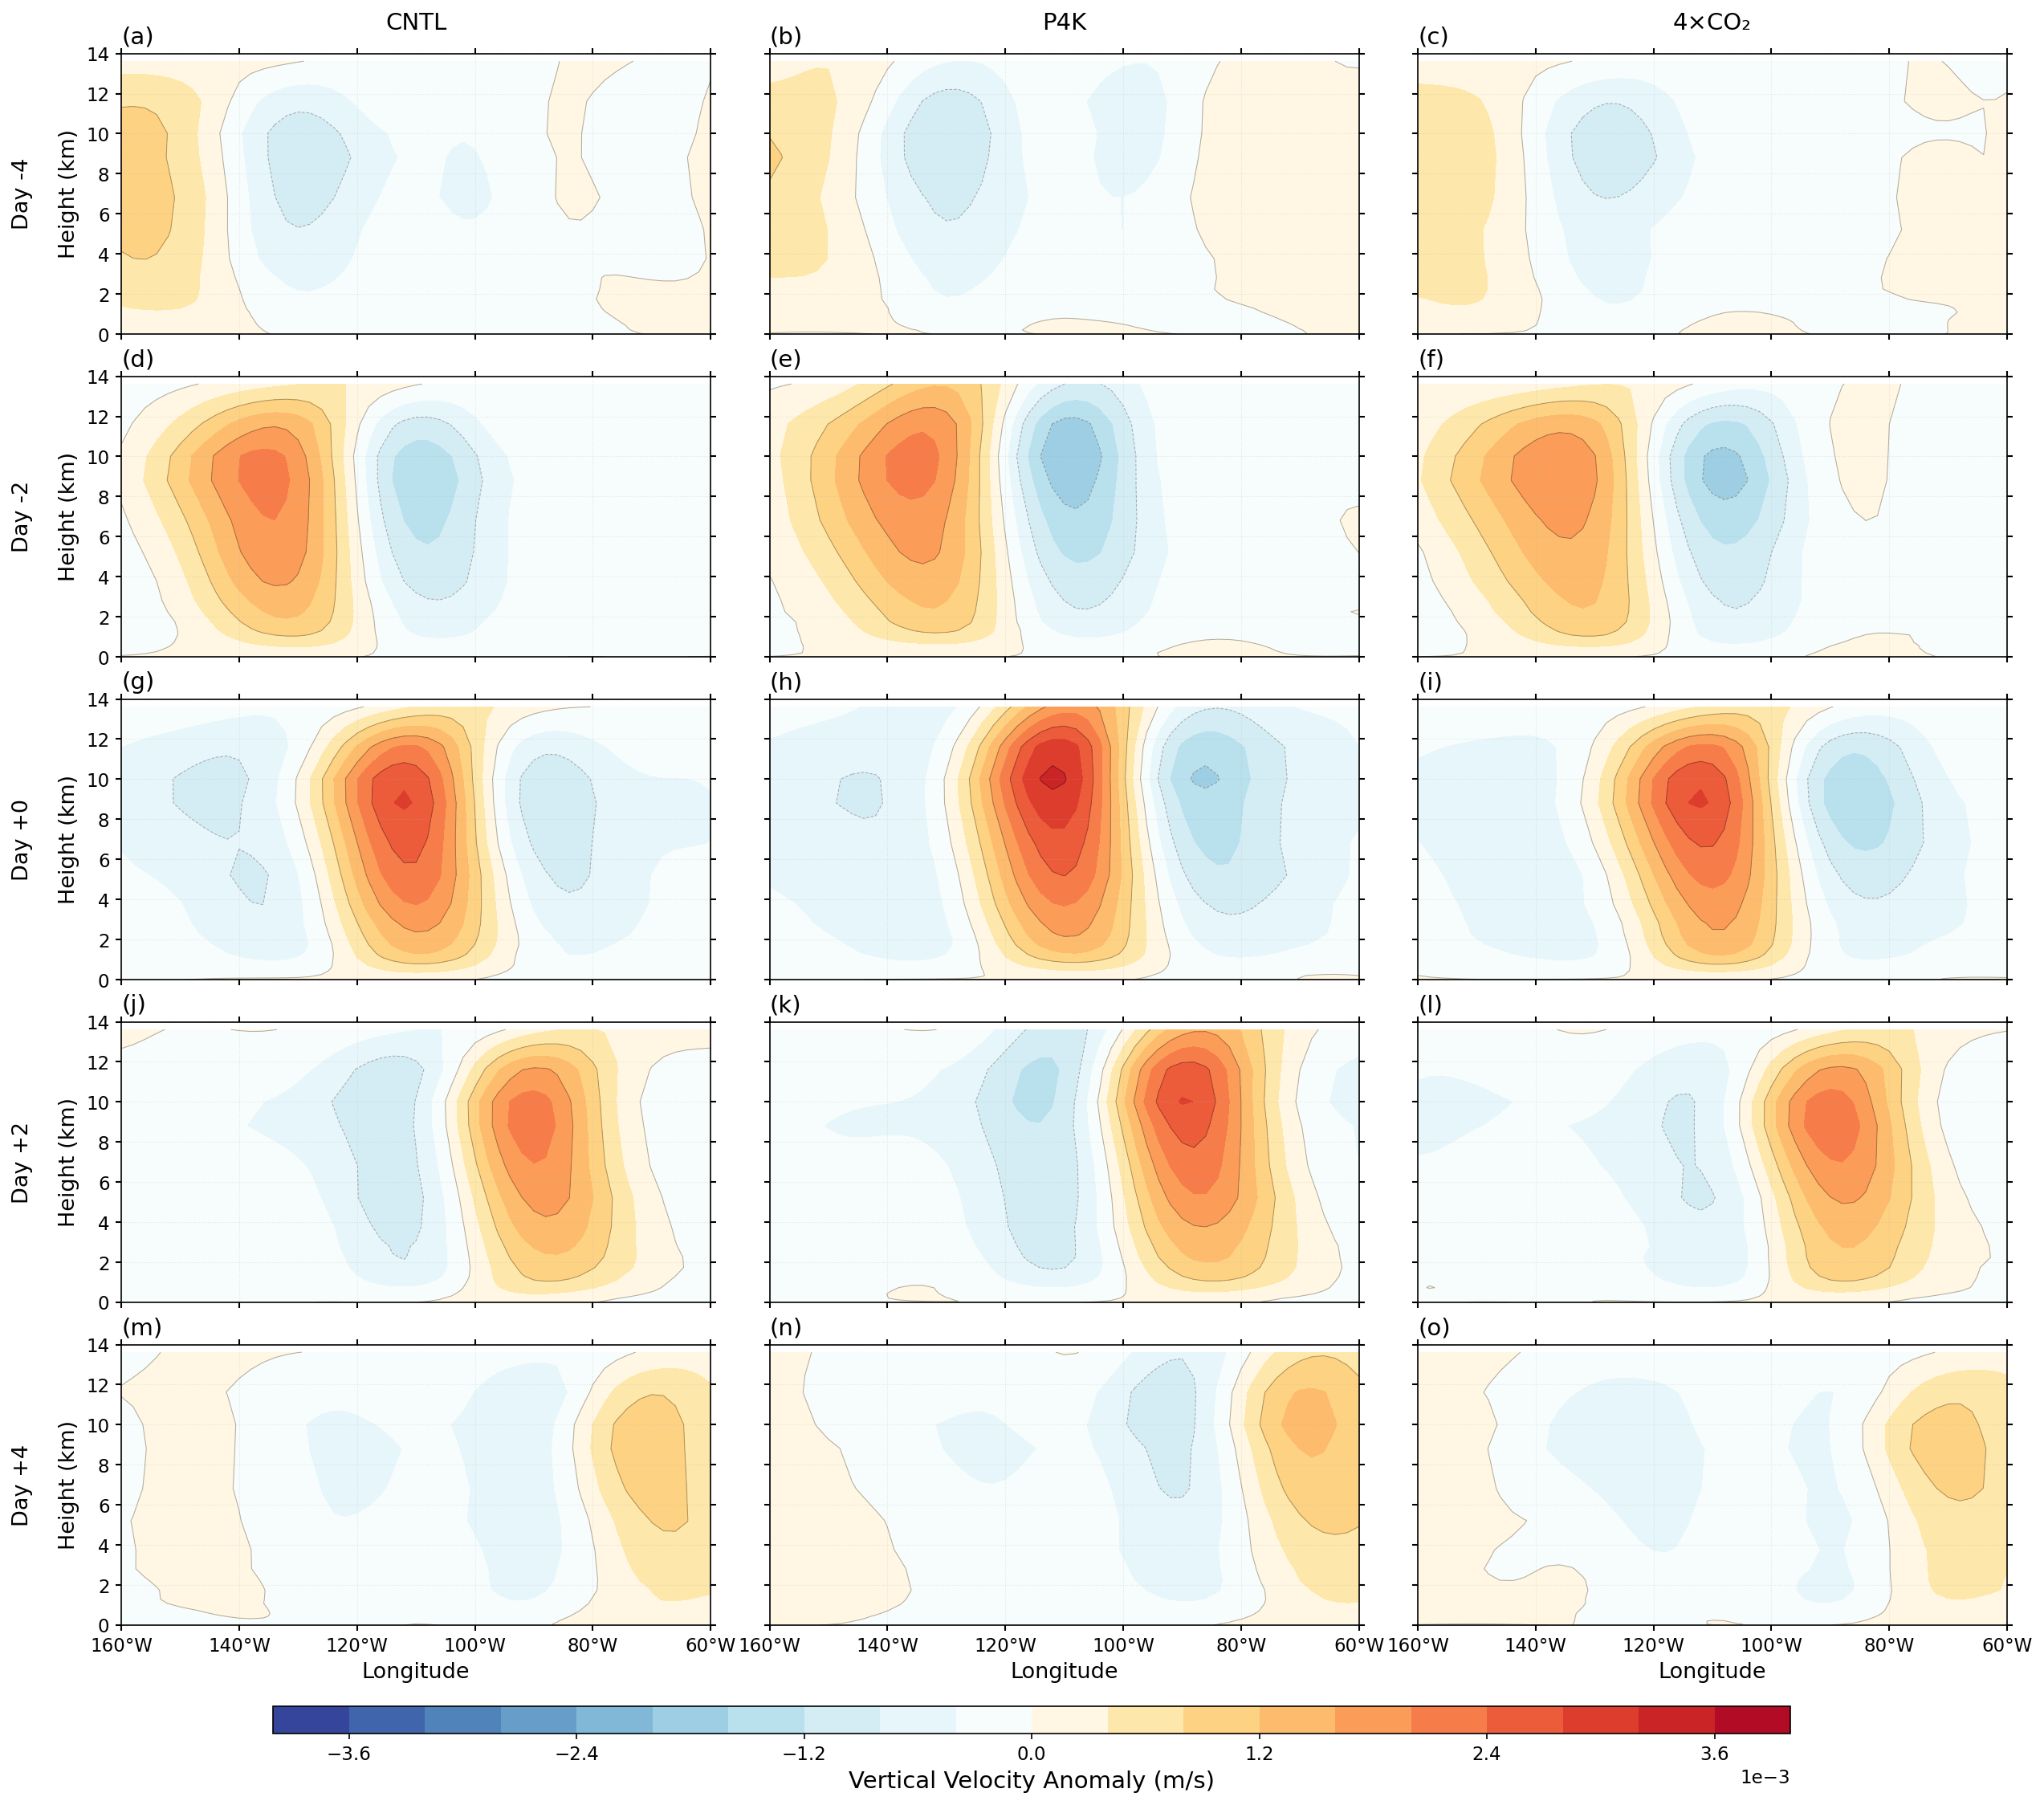


💾 Figure saved: ../figures/vertical_profile_composite/wa_lon_height_composite_all_lags.png


In [5]:
def plot_wa_lon_height_composite(  
        wa_composites,
        experiments=['CNTL', 'P4K', '4CO2'],
        lags=[-4, -2, 0, 2, 4],
        lat_range=(5, 15),
        lon_range=(200, 300),
        figsize=(20, 12),
        height_range=None):
    """
    绘制wa的经度-高度剖面组合图
    
    每行：3个实验 (CNTL, P4K, 4CO2)
    每列：不同的lag天数
    
    Parameters:
    -----------
    wa_composites : dict
        {exp: xr.DataArray} wa合成数据，维度应为 (lag, height, lat, lon)
    experiments : list
        实验列表
    lags : list
        要绘制的lag天数列表
    lat_range : tuple
        纬度范围
    lon_range : tuple
        经度范围
    figsize : tuple
        图形大小
    height_range : tuple or None
        高度范围（km），None表示使用全部
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
    """
    
    n_lags = len(lags)
    n_exps = len(experiments)
    
    # 创建子图：n_lags行 × n_exps列
    fig, axes = plt.subplots(n_lags, n_exps, figsize=figsize, dpi=150)
    
    # 如果只有一行或一列，确保axes是2D数组
    if n_lags == 1 and n_exps == 1:
        axes = np.array([[axes]])
    elif n_lags == 1:
        axes = axes.reshape(1, -1)
    elif n_exps == 1:
        axes = axes.reshape(-1, 1)
    
    # 实验标题
    exp_titles = {
        'CNTL': 'CNTL',
        'P4K': 'P4K',
        '4CO2': '4×CO₂'
    }
    titles_sub = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)']
    # 创建colormap
    colors_list = [
        '#313695', '#4575b4', '#74add1', '#abd9e9', '#e0f3f8',
        'white',    
        '#fee090', '#fdae61', '#f46d43', '#d73027', '#a50026'
    ]
    cmap = LinearSegmentedColormap.from_list('wa_cmap', colors_list)    
    # 设置colorbar范围（需要根据实际数据调整）
    vmin, vmax = -4e-3, 4e-3   # 单位：m/s
    levels = np.linspace(vmin, vmax, 21)
    print("\n" + "="*70)
    print("🎨 Plotting wa longitude-height composite")
    print("="*70)
    # 遍历每个lag和实验
    for row_idx, lag in enumerate(lags):
        for col_idx, exp in enumerate(experiments):
            ax = axes[row_idx, col_idx]
            ax.set_title(f"({chr(97 + row_idx * len(experiments) + col_idx)})", fontsize=14, loc='left')
            if exp not in wa_composites:
                print(f"  ⚠️  {exp} lag={lag}: Data not found")
                ax.text(0.5, 0.5, 'Data not available', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            wa_da = wa_composites[exp]
            # 识别高度维度名称
            if 'height' in wa_da.dims:
                height_dim = 'height'
            elif 'lev' in wa_da.dims:   
                height_dim = 'lev'
            elif 'level' in wa_da.dims:
                height_dim = 'level'
            else:
                print(f"  ⚠️  {exp}: No height dimension found")
                continue
            # 数据选择：lag, lat平均, lon
            try:
                wa_data = (
                    wa_da
                    .sel(lag=lag, lat=slice(*lat_range), lon=slice(*lon_range))
                    .mean(dim='lat')
                )
            except Exception as e:
                print(f"  ⚠️  {exp} lag={lag}: Error selecting data - {str(e)}")
                continue
            # 获取坐标
            lon_vals = wa_data.lon.values
            height_vals = wa_data[height_dim].values  # 单位：km
            # 如果指定了高度范围，进行筛选
            if height_range is not None:
                mask = (height_vals >= height_range[0]) & (height_vals <= height_range[1])
                if mask.sum() == 0:
                    print(f"  ⚠️  {exp} lag={lag}: No data in specified height range")
                    continue
                wa_data = wa_data.isel({height_dim: mask})
                height_vals = height_vals[mask]
            # 创建网格
            LON, HEIGHT = np.meshgrid(lon_vals, height_vals)
            # 绘制填色图
            cf = ax.contourf(LON, HEIGHT, wa_data.values,
                           levels=levels, cmap=cmap, extend='neither')
            # 绘制等值线
            cs = ax.contour(LON, HEIGHT, wa_data.values,
                          levels=levels[::2], colors='k', alpha=0.3, linewidths=0.5)
            # 设置y轴（高度）
            ax.set_ylim(height_vals.min(), 15)
            height_min = int(np.ceil(height_vals.min()))
            height_max = min(15, int(np.floor(height_vals.max())))
            yticks = np.arange(0, 15, 2)
            ax.set_yticks(yticks)
            ax.set_ylim(0,14)
            # 只在最左列显示y轴标签
            if col_idx == 0:    
                ax.set_yticklabels([f"{int(h)}" for h in yticks], fontsize=12)
                ax.set_ylabel('Height (km)', fontsize=13)
            else:
                ax.set_yticklabels([])
            # 设置x轴（经度）
            def east_longitude_formatter(x, pos):
                val = x % 360
                return f"{int(val)}°E"
            from cartopy.mpl.ticker import LongitudeFormatter
            ax.xaxis.set_major_formatter(LongitudeFormatter())
            # ax.xaxis.set_major_formatter(plt.FuncFormatter(east_longitude_formatter))
            ax.set_xticks(np.arange(lon_range[0], lon_range[1]+1, 20))
            # 只在最下行显示x轴标签
            if row_idx == n_lags - 1:
                ax.tick_params(axis='x', labelsize=11)
                ax.set_xlabel('Longitude', fontsize=13)
            else:
                ax.set_xticklabels([])
            # 标题：最上行显示实验名，最左列显示lag
            if row_idx == 0:
                ax.set_title(f"{exp_titles.get(exp, exp)}", fontsize=14,y=1.05)
            if col_idx == 0:
                # 在图的左侧添加lag标签
                ax.text(-0.15, 0.5, f"Day {lag:+d}", 
                       transform=ax.transAxes, fontsize=13, 
                       rotation=90, va='center', ha='right')    
            # 网格
            ax.grid(True, linestyle=':', alpha=0.3, linewidth=0.5)
            # 刻度参数
            ax.tick_params(which='both', direction='out', width=1.0,
                          labelsize=11, bottom=True, left=True,
                          right=True, top=True)
            print(f"  ✅ {exp} lag={lag}: Plotted")
    # 调整子图间距
    plt.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                       hspace=0.15, wspace=0.1)
    # 添加全局colorbar
    cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.015])
    cbar = plt.colorbar(cf, cax=cbar_ax, orientation='horizontal', extend='both')
    cbar.set_label(r'Vertical Velocity Anomaly (m/s)', fontsize=14)
    cbar.ax.tick_params(labelsize=11)
    # 格式化colorbar刻度为科学计数法
    cbar.formatter.set_powerlimits((-2, 2))
    cbar.ax.xaxis.offsetText.set_fontsize(11)
    cbar.update_ticks()
    print("\n" + "="*70)
    print("✅ Plotting completed")
    print("="*70)
    return fig  
# 使用示例
print("✅ Function defined: plot_wa_lon_height_composite")
print("\n💡 Usage:")
print("   fig = plot_wa_lon_height_composite(")
print("       wa_composite_data,")
print("       experiments=['CNTL', 'P4K', '4CO2'],")
print("       lags=[-4, -2, 0, 2, 4],")
print("       lat_range=(5, 15),")
print("       lon_range=(200, 300),")
print("       height_range=(0, 15)")    
print("   )")
# 绘制wa经度-高度剖面组合图
print("\n🎨 Creating wa longitude-height composite figure...")
fig_wa = plot_wa_lon_height_composite(
    wa_composites=wa_composite_data,
    experiments=['CNTL', 'P4K', '4CO2'],
    lags=[-4, -2, 0, 2, 4],
    lat_range=(5, 15),
    lon_range=(200, 300),
    figsize=(18, 15),
    height_range=(0, 15)  # 0-15km高度范围
)
plt.show()
# 可选：保存图片
save_fig = True
if save_fig:    
    save_dir = '../figures/vertical_profile_composite/'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, 'wa_lon_height_composite_all_lags.png')
    fig_wa.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n💾 Figure saved: {save_path}")

## 可选：单个lag天数的对比图（3个实验并排）

In [6]:
# # 可选：绘制单个lag天数的3个实验对比
# single_lag = 0  # 选择Day 0

# fig_single = plot_hus_lon_height_composite(
#     hus_composites=hus_composite_data,
#     experiments=['CNTL', 'P4K', '4CO2'],
#     lags=[single_lag],  # 只选一个lag
#     lat_range=(-5, 15),
#     lon_range=(200, 300),
#     figsize=(18, 5),
#     height_range=(0, 15)
# )

# plt.suptitle(f'Specific Humidity Composite at Day {single_lag:+d} (5°N-15°N average)', 
#              fontsize=16, fontweight='bold', y=1.02)

# plt.show()

# # 保存
# if save_fig:
#     save_path_single = os.path.join(save_dir, f'hus_lon_height_composite_day{single_lag:+d}.png')
#     fig_single.savefig(save_path_single, dpi=300, bbox_inches='tight')
#     print(f"💾 Figure saved: {save_path_single}")


🎨 Creating wa difference plot: P4K - CNTL...

🎨 Plotting wa difference: P4K - CNTL
  ✅ lag=-1: Plotted
  ✅ lag=0: Plotted
  ✅ lag=1: Plotted


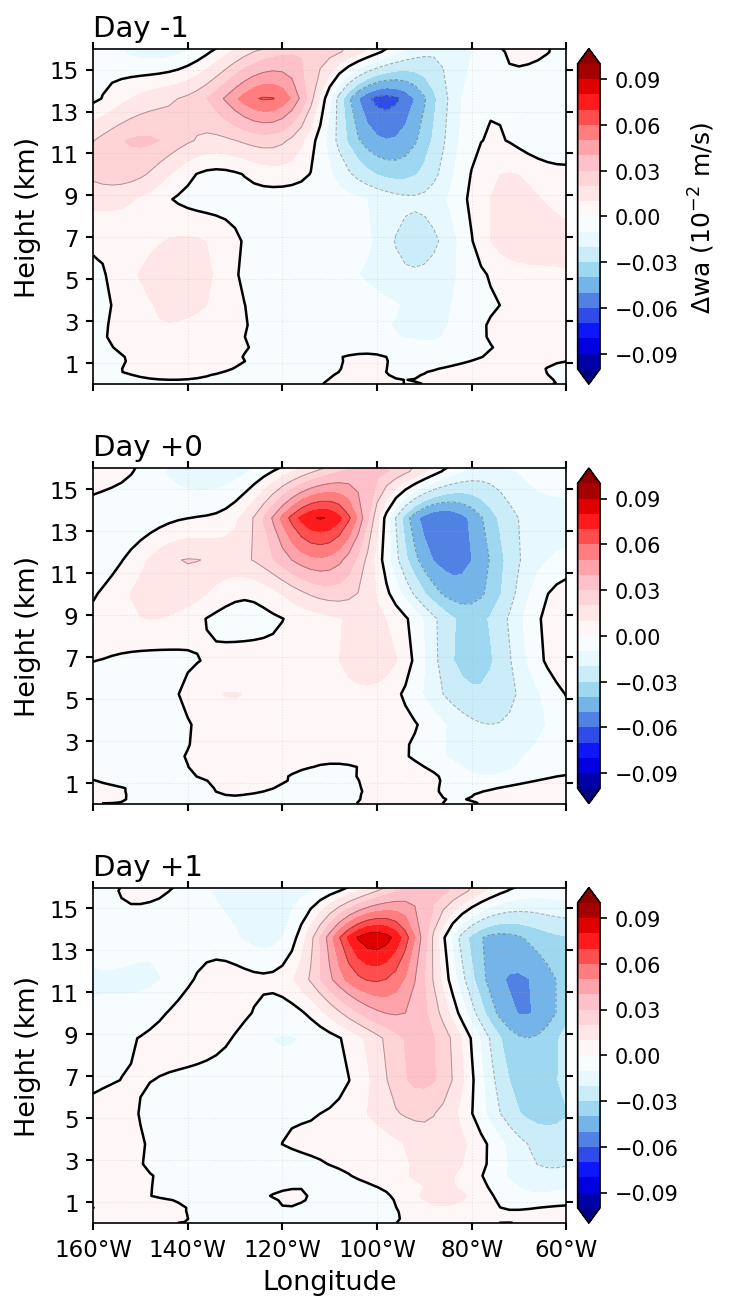


💾 Figure saved: ../figures/vertical_profile_composite/wa_difference_P4K-CNTL_vertical.png


In [7]:
def plot_wa_difference_vertical(
        wa_composites,
        reference_exp='CNTL',
        difference_exp='P4K',
        lags=[-4, -2, 0, 2, 4],
        lat_range=(5, 15),
        lon_range=(200, 300),
        figsize=(10, 12),
        height_range=None):
    """
    绘制wa的P4K-CNTL差异的垂直剖面图
    
    每行显示一个lag天数的差异
    
    Parameters:
    -----------
    wa_composites : dict
        {exp: xr.DataArray} wa合成数据
    reference_exp : str
        参考实验 (通常是CNTL)
    difference_exp : str
        对比实验 (通常是P4K或4CO2)
    lags : list
        要绘制的lag天数
    lat_range : tuple
        纬度范围
    lon_range : tuple
        经度范围
    figsize : tuple
        图形大小
    height_range : tuple or None
        高度范围(km)
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
    """
    
    n_lags = len(lags)
    
    # 创建子图
    fig, axes = plt.subplots(n_lags, 1, figsize=figsize, dpi=150)
    
    if n_lags == 1:
        axes = [axes]
    
    # 创建colormap - 差异用红蓝色
    colors_list = [
        '#053061', '#2166ac', '#4393c3', '#92c5de', '#d1e5f0',
        'white',
        '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f'
    ]
    cmap_diff = LinearSegmentedColormap.from_list('wa_diff', colors_list)
    
    print("\n" + "="*70)
    print(f"🎨 Plotting wa difference: {difference_exp} - {reference_exp}")
    print("="*70)
    
    # 检查数据是否存在
    if reference_exp not in wa_composites or difference_exp not in wa_composites:
        print(f"❌ Missing data for {reference_exp} or {difference_exp}")
        return None
    
    wa_ref = wa_composites[reference_exp]
    wa_diff_exp = wa_composites[difference_exp]
    
    # 识别高度维度
    if 'height' in wa_ref.dims:
        height_dim = 'height'
    elif 'lev' in wa_ref.dims:
        height_dim = 'lev'
    elif 'level' in wa_ref.dims:
        height_dim = 'level'
    else:
        print("❌ No height dimension found")
        return None
    
    # 计算差异
    wa_difference = wa_diff_exp - wa_ref
    
    for row_idx, lag in enumerate(lags):
        ax = axes[row_idx]
        
        try:
            # 选择数据
            wa_diff_data = (
                wa_difference
                .sel(lag=lag, lat=slice(*lat_range), lon=slice(*lon_range))
                .mean(dim='lat')
            )
            
            # 获取坐标
            lon_vals = wa_diff_data.lon.values
            height_vals = wa_diff_data[height_dim].values
            
            # 如果高度是压力层，需要转换
            if height_vals.max() > 1000:  # 判断是否是Pa单位
                height_vals = height_vals / 1000.0  # 转换为km（假设已经是米）
            
            # 高度范围筛选
            if height_range is not None:
                mask = (height_vals >= height_range[0]) & (height_vals <= height_range[1])
                if mask.sum() == 0:
                    print(f"  ⚠️  lag={lag}: No data in height range")
                    continue
                wa_diff_data = wa_diff_data.isel({height_dim: mask})
                height_vals = height_vals[mask]
            
            # 创建网格
            LON, HEIGHT = np.meshgrid(lon_vals, height_vals)
            
            # 转换单位：Pa/s -> 10^-2 m/s
            wa_diff_plot = wa_diff_data.values * 100
            
            # 设置colorbar范围
            vmax = np.nanpercentile(np.abs(wa_diff_plot), 95)
            vmax = max(vmax, 0.1)  # 至少0.1
            levels = np.linspace(-vmax, vmax, 21)
            
            # 填色图
            cf = ax.contourf(LON, HEIGHT, wa_diff_plot, 
                           levels=levels, cmap=mycmap, extend='both')
            
            # 等值线
            cs = ax.contour(LON, HEIGHT, wa_diff_plot,
                          levels=levels[::2], colors='k', alpha=0.3, linewidths=0.5)
            
            # 添加零线（加粗）
            ax.contour(LON, HEIGHT, wa_diff_plot,
                      levels=[0], colors='black', linewidths=1.2, linestyles='-')
            
            # 设置y轴
            ax.set_ylim(height_vals.min(), 15)
            height_min = int(np.ceil(height_vals.min()))
            height_max = min(15, int(np.floor(height_vals.max())))
            yticks = np.arange(height_min, height_max+1, 2)
            ax.set_yticks(yticks)
            ax.set_yticklabels([f"{int(h)}" for h in yticks], fontsize=12)
            ax.set_ylabel('Height (km)', fontsize=13)
            ax.set_ylim(0,16)
            # 设置x轴
            def east_longitude_formatter(x, pos):
                val = x % 360
                return f"{int(val)}°E"
            
            from cartopy.mpl.ticker import LongitudeFormatter
            ax.xaxis.set_major_formatter(LongitudeFormatter())
            ax.set_xticks(np.arange(lon_range[0], lon_range[1]+1, 20))
            
            if row_idx == n_lags - 1:
                ax.tick_params(axis='x', labelsize=11)
                ax.set_xlabel('Longitude', fontsize=13)
            else:
                ax.set_xticklabels([])
            
            # 标题
            ax.set_title(f"Day {lag:+d}", loc='left', fontsize=14)
            
            # 网格
            ax.grid(True, linestyle=':', alpha=0.3, linewidth=0.5)
            
            # 刻度
            ax.tick_params(which='both', direction='out', width=1.0,
                          labelsize=11, bottom=True, left=True,
                          right=True, top=True)
            
            # colorbar（每个子图都添加）
            cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02, aspect=15)
            if row_idx == 0:
                cbar.set_label(r'$\Delta$wa ($10^{-2}$ m/s)', fontsize=12)
            cbar.ax.tick_params(labelsize=10)
            
            print(f"  ✅ lag={lag}: Plotted")
            
        except Exception as e:
            print(f"  ❌ lag={lag}: Error - {str(e)}")
            import traceback
            traceback.print_exc()
            continue
    
    # 调整布局
    plt.subplots_adjust(left=0.12, right=0.88, top=0.95, bottom=0.08, hspace=0.25)
    
  
    
    return fig

# 绘制P4K-CNTL的wa差异
print("\n🎨 Creating wa difference plot: P4K - CNTL...")

fig_wa_diff = plot_wa_difference_vertical(
    wa_composites=wa_composite_data,
    reference_exp='CNTL',
    difference_exp='P4K',
    lags=[-1, 0, 1, ],
    lat_range=(0, 15),
    lon_range=(200, 300),
    figsize=(5, 9),
    height_range=(0, 18)
)

plt.show()

# 保存图片
save_fig = True
if save_fig and fig_wa_diff is not None:
    save_dir = '../figures/vertical_profile_composite/'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, 'wa_difference_P4K-CNTL_vertical.png')
    fig_wa_diff.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n💾 Figure saved: {save_path}")


🎨 Plotting wa difference: P4K - CNTL
  ✅ lag=-4: Plotted
  ✅ lag=-2: Plotted
  ✅ lag=0: Plotted
  ✅ lag=2: Plotted
  ✅ lag=4: Plotted


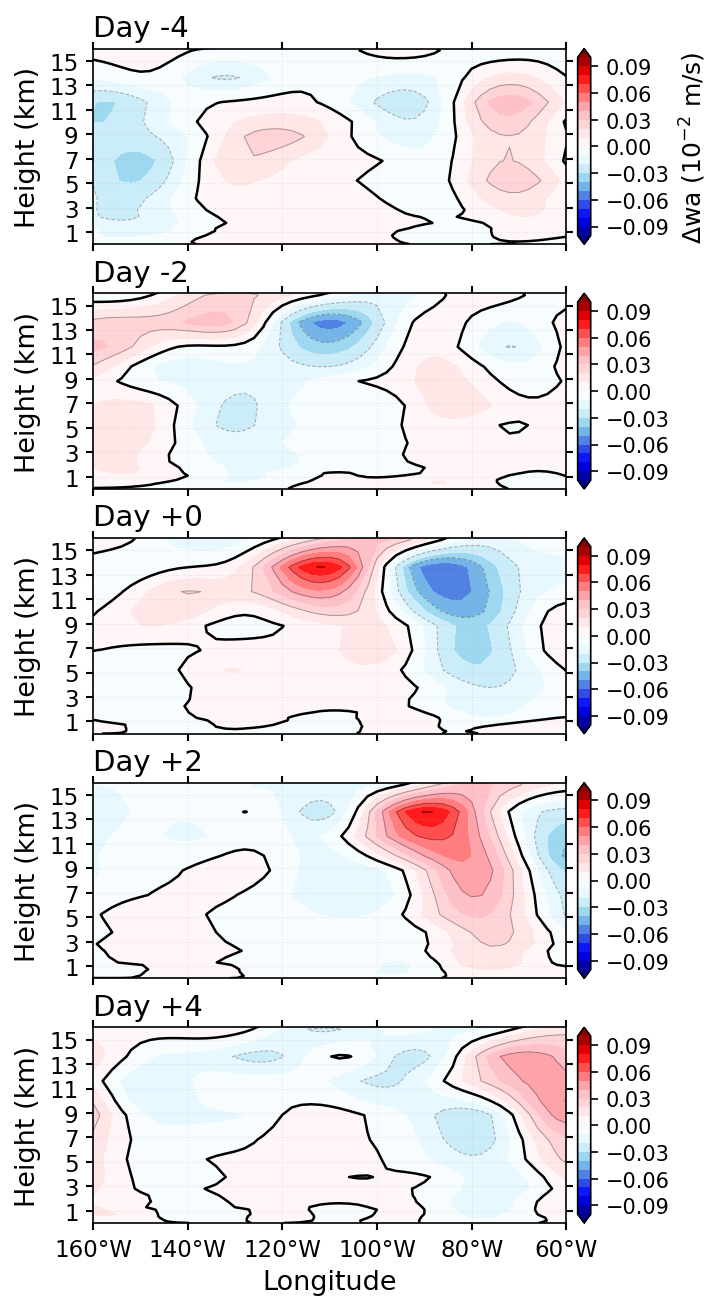

In [8]:
fig_wa_diff = plot_wa_difference_vertical(
    wa_composites=wa_composite_data,
    reference_exp='CNTL',
    difference_exp='P4K',
    lags=[-4,-2, 0, 2, 4],
    lat_range=(0, 15),
    lon_range=(200, 300),
    figsize=(5, 9),
    height_range=(0, 18)
)

plt.show()

### 可选：绘制4CO2-CNTL的差异

In [9]:
# # 可选：绘制4CO2-CNTL的wa差异
# print("\n🎨 Creating wa difference plot: 4CO2 - CNTL...")

# fig_wa_diff_4co2 = plot_wa_difference_vertical(
#     wa_composites=wa_composite_data,
#     reference_exp='CNTL',
#     difference_exp='4CO2',
#     lags=[-4, -2, 0, 2, 4],
#     lat_range=(5, 15),
#     lon_range=(200, 300),
#     figsize=(10, 14),
#     height_range=(0, 15)
# )

# plt.show()

# # 保存
# if save_fig and fig_wa_diff_4co2 is not None:
#     save_path_4co2 = os.path.join(save_dir, 'wa_difference_4CO2-CNTL_vertical.png')
#     fig_wa_diff_4co2.savefig(save_path_4co2, dpi=300, bbox_inches='tight')
#     print(f"💾 Figure saved: {save_path_4co2}")

### 并排对比：P4K-CNTL 和 4CO2-CNTL

In [10]:
# def plot_wa_difference_comparison(
#         wa_composites,
#         reference_exp='CNTL',
#         difference_exps=['P4K', '4CO2'],
#         lags=[-4, -2, 0, 2, 4],
#         lat_range=(5, 15),
#         lon_range=(200, 300),
#         figsize=(18, 14),
#         height_range=None):
#     """
#     并排对比两个实验与CNTL的差异
    
#     每行：一个lag
#     每列：一个差异实验
#     """
    
#     n_lags = len(lags)
#     n_diffs = len(difference_exps)
    
#     fig, axes = plt.subplots(n_lags, n_diffs, figsize=figsize, dpi=150)
    
#     if n_lags == 1 and n_diffs == 1:
#         axes = np.array([[axes]])
#     elif n_lags == 1:
#         axes = axes.reshape(1, -1)
#     elif n_diffs == 1:
#         axes = axes.reshape(-1, 1)
    
#     # Colormap
#     colors_list = [
#         '#053061', '#2166ac', '#4393c3', '#92c5de', '#d1e5f0',
#         'white',
#         '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f'
#     ]
#     cmap_diff = LinearSegmentedColormap.from_list('wa_diff', colors_list)
    
#     print("\n" + "="*70)
#     print(f"🎨 Plotting wa difference comparison")
#     print("="*70)
    
#     wa_ref = wa_composites.get(reference_exp)
#     if wa_ref is None:
#         print(f"❌ Missing reference data: {reference_exp}")
#         return None
    
#     # 识别高度维度
#     if 'height' in wa_ref.dims:
#         height_dim = 'height'
#     elif 'lev' in wa_ref.dims:
#         height_dim = 'lev'
#     elif 'level' in wa_ref.dims:
#         height_dim = 'level'
#     else:
#         print("❌ No height dimension found")
#         return None
    
#     for col_idx, diff_exp in enumerate(difference_exps):
#         wa_diff_exp = wa_composites.get(diff_exp)
#         if wa_diff_exp is None:
#             print(f"⚠️  Missing data: {diff_exp}")
#             continue
        
#         # 计算差异
#         wa_difference = wa_diff_exp - wa_ref
        
#         for row_idx, lag in enumerate(lags):
#             ax = axes[row_idx, col_idx]
            
#             try:
#                 # 选择数据
#                 wa_diff_data = (
#                     wa_difference
#                     .sel(lag=lag, lat=slice(*lat_range), lon=slice(*lon_range))
#                     .mean(dim='lat')
#                 )
                
#                 lon_vals = wa_diff_data.lon.values
#                 height_vals = wa_diff_data[height_dim].values
                
#                 if height_vals.max() > 1000:
#                     height_vals = height_vals / 1000.0
                
#                 if height_range is not None:
#                     mask = (height_vals >= height_range[0]) & (height_vals <= height_range[1])
#                     if mask.sum() > 0:
#                         wa_diff_data = wa_diff_data.isel({height_dim: mask})
#                         height_vals = height_vals[mask]
                
#                 LON, HEIGHT = np.meshgrid(lon_vals, height_vals)
#                 wa_diff_plot = wa_diff_data.values * 100
                
#                 vmax = np.nanpercentile(np.abs(wa_diff_plot), 95)
#                 vmax = max(vmax, 0.1)
#                 levels = np.linspace(-vmax, vmax, 21)
                
#                 cf = ax.contourf(LON, HEIGHT, wa_diff_plot,
#                                levels=levels, cmap=cmap_diff, extend='both')
                
#                 ax.contour(LON, HEIGHT, wa_diff_plot,
#                           levels=levels[::2], colors='k', alpha=0.3, linewidths=0.5)
                
#                 ax.contour(LON, HEIGHT, wa_diff_plot,
#                           levels=[0], colors='black', linewidths=1.5)
                
#                 # Y轴
#                 ax.set_ylim(height_vals.min(), 15)
#                 height_min = int(np.ceil(height_vals.min()))
#                 height_max = min(15, int(np.floor(height_vals.max())))
#                 yticks = np.arange(height_min, height_max+1, 2)
#                 ax.set_yticks(yticks)
                
#                 if col_idx == 0:
#                     ax.set_yticklabels([f"{int(h)}" for h in yticks], fontsize=11)
#                     ax.set_ylabel('Height (km)', fontsize=12)
#                     # 添加lag标签
#                     ax.text(-0.25, 0.5, f"Day {lag:+d}",
#                            transform=ax.transAxes, fontsize=13, fontweight='bold',
#                            rotation=90, va='center', ha='right')
#                 else:
#                     ax.set_yticklabels([])
                
#                 # X轴
#                 def east_longitude_formatter(x, pos):
#                     val = x % 360
#                     return f"{int(val)}°E"
                
#                 ax.xaxis.set_major_formatter(plt.FuncFormatter(east_longitude_formatter))
#                 ax.set_xticks(np.arange(lon_range[0], lon_range[1]+1, 20))
                
#                 if row_idx == n_lags - 1:
#                     ax.tick_params(axis='x', labelsize=10)
#                     ax.set_xlabel('Longitude', fontsize=12)
#                 else:
#                     ax.set_xticklabels([])
                
#                 # 顶部标题
#                 if row_idx == 0:
#                     title = f"{diff_exp} - {reference_exp}"
#                     ax.set_title(title, fontsize=13, fontweight='bold')
                
#                 ax.grid(True, linestyle=':', alpha=0.3, linewidth=0.5)
#                 ax.tick_params(which='both', direction='out', width=1.0,
#                               labelsize=10, bottom=True, left=True,
#                               right=True, top=True)
                
#             except Exception as e:
#                 print(f"  ❌ {diff_exp} lag={lag}: Error - {str(e)}")
#                 continue
    
#     # 调整布局
#     plt.subplots_adjust(left=0.1, right=0.95, top=0.94, bottom=0.08,
#                        hspace=0.15, wspace=0.12)
    
#     # 全局colorbar
#     cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.015])
#     cbar = plt.colorbar(cf, cax=cbar_ax, orientation='horizontal', extend='both')
#     cbar.set_label(r'$\Delta$wa ($10^{-2}$ m/s)', fontsize=13, fontweight='bold')
#     cbar.ax.tick_params(labelsize=11)
    
#     # 总标题
#     fig.suptitle('Vertical Velocity Differences from CNTL (5°N-15°N average)',
#                 fontsize=15, fontweight='bold', y=0.98)
    
#     print("\n✅ Comparison plot completed")
    
#     return fig

# print("✅ Function defined: plot_wa_difference_comparison")
# 绘制并排对比图
# print("\n🎨 Creating side-by-side comparison: P4K-CNTL vs 4CO2-CNTL...")

# fig_comparison = plot_wa_difference_comparison(
#     wa_composites=wa_composite_data,
#     reference_exp='CNTL',
#     difference_exps=['P4K', '4CO2'],
#     lags=[-4, -2, 0, 2, 4],
#     lat_range=(5, 15),
#     lon_range=(200, 300),
#     figsize=(16, 15),
#     height_range=(0, 15)
# )

# plt.show()

# # 保存
# if save_fig and fig_comparison is not None:
#     save_path_comp = os.path.join(save_dir, 'wa_difference_comparison_vertical.png')
#     fig_comparison.savefig(save_path_comp, dpi=300, bbox_inches='tight')
#     print(f"💾 Figure saved: {save_path_comp}")

# print("\n" + "="*70)
# print("✅ All wa difference plots completed!")
# print("="*70)